# Notebook Guide to Frequency Processing

### Orbit Correction
First, lets correct for orbital motion! This can be called from the orbit_correction.py file.

In [1]:
from orbit_correction import *

In [2]:
target_id = '799'           # Barycenter code for Uranus
observer_id = '@tess'          
flux_data_file = '/scratch11/ktp9/TESS_SolarSystem/Uranus/s44_cam1_ccd4/results_bps40_pps10/lc_Uranus_s44_cam1_ccd4.txt'

In [3]:
times, raw_flux, corrected_lightcurve = run_orbit_correction(target_id, observer_id, flux_data_file)

Parsing Light Curve
Getting ephemeris
Correcting Light curve


We can see that you only need a few lines of code for this, and the light curve file from the _tess-solarsystem_ code. Lets see how the correction compares to the raw flux.

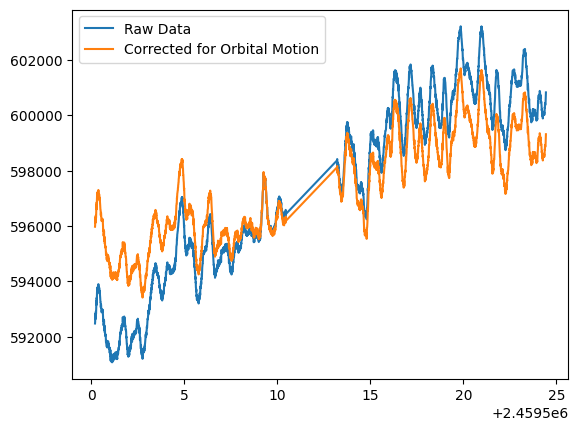

In [4]:
import matplotlib.pyplot as plt 

plt.plot(times, raw_flux, label="Raw Data")
plt.plot(times, corrected_lightcurve, label="Corrected for Orbital Motion")
plt.legend()
plt.show()

### Periodogram Analysis

Next, lets look at the peak periodicities in this light curve. 

In [5]:
from frequency_processing import *

In [6]:
frequency, power, false_alarm_array = makePeriodogram(times, corrected_lightcurve, 0.05, 3, 10, 1)

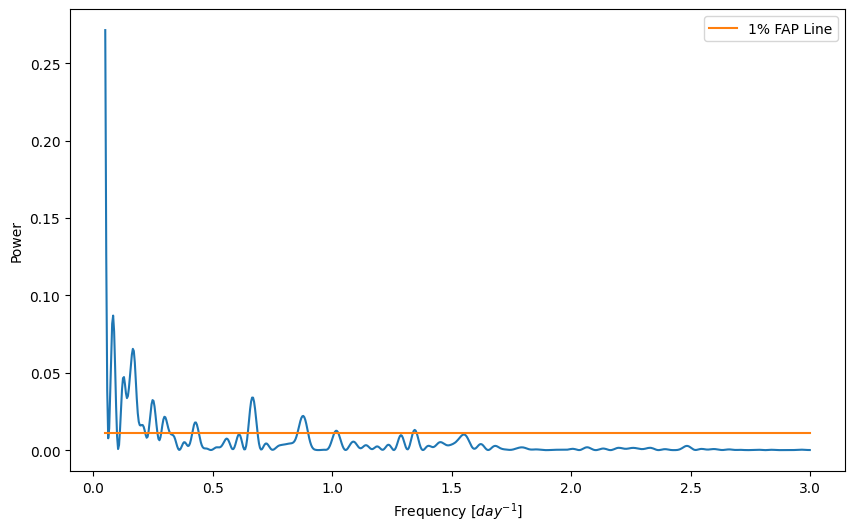

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(frequency, power)
plt.plot(frequency, false_alarm_array, label="1% FAP Line")
plt.legend()
plt.xlabel(r"Frequency $[day^{-1}]$")
plt.ylabel("Power")
plt.show()

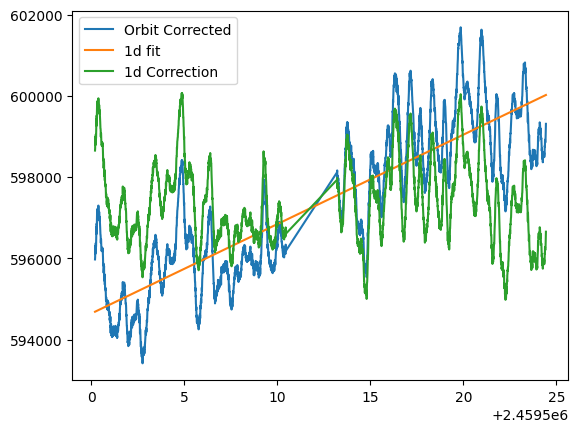

In [8]:
linear_fit, line, detrended = linear_detrend(times, corrected_lightcurve)

plt.plot(times, corrected_lightcurve, label="Orbit Corrected")
plt.plot(times, line, label="1d fit")
plt.plot(times, detrended, label="1d Correction")
plt.legend()
plt.show()

In [9]:
frequency_dt, power_dt, false_alarm_array_dt = makePeriodogram(times, detrended, 0.05, 3, 10, 1)

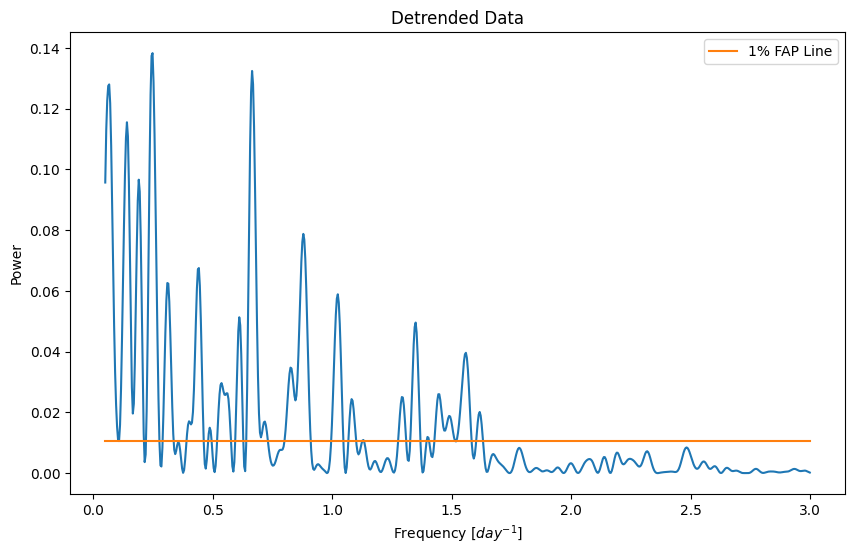

In [10]:
plt.figure(figsize=(10, 6))
plt.title("Detrended Data")
plt.plot(frequency_dt, power_dt)
plt.plot(frequency_dt, false_alarm_array_dt, label="1% FAP Line")
plt.legend()
plt.xlabel(r"Frequency $[day^{-1}]$")
plt.ylabel("Power")
plt.show()

In [11]:
peaks = get_peak_frequencies(frequency_dt, power_dt, false_alarm_array_dt)

### MCMC sampling

Great! So we have our detrended periodogram and our peak frequencies. Now, lets convert these to latitudes.